In [148]:
# Written by: Parsa Toopchinezhad
# Date: 2025-02-12
# Description: This script loads the Puffer dataset, performs basic data analysis, visualizes key metrics, and trains basic tree-based models on it


# Step 0: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [149]:
def load_puffer_dataset():
    try:
        df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")
    except FileNotFoundError:
        response = requests.get("https://storage.googleapis.com/puffer-data-release/2025-02-10T11_2025-02-11T11/video_sent_2025-02-10T11_2025-02-11T11.csv")
        with open("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv", 'wb') as f:
            f.write(response.content)
        df = pd.read_csv("2025-02-10T11_2025-02-11T11_video_sent_2025-02-10T11_2025-02-11T11.csv")
    # Step 2: Remove unnecessary columns & rename columns
    #df = df.drop(columns=['session_id', 'channel', 'format'])
    df = df.rename(columns={'time (ns GMT)': 'time'})
    # make time relative to start of session and convert to seconds
    df['time'] = (df['time'] - df['time'].min()) / 1e9
    return df
    

# LSTM

In [151]:
import torch
import torch.nn as nn
import random
from torch.utils.data import Dataset, DataLoader, TensorDataset

SEQ_LEN = 10       # length of input sequence (timesteps)
HIDDEN_DIM = 128
NUM_LAYERS = 4
BATCH_SIZE = 512
LR = 1e-4
EPOCHS = 100
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [152]:
class LSTM_regressor(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, num_layers, dropout, bidirectional=False):
        super().__init__()
        self.in_dim = in_d
        self.out_dim = out_d
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size=self.in_dim, hidden_size=hidden_d, num_layers=self.num_layers, batch_first=True, dropout=dropout)
        self.dense_out = nn.Linear(hidden_d, self.out_dim)
        
    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_output = out[:, -1, :]
        output = self.dense_out(last_output)
        return output

In [153]:
def form_sliding_windows(df_groups, regression_target, regress_based_on, n_lags, horizon, feature_cols):
    X_windows = []
    y_windows = []
    for id, group in df_groups:
        g = group.sort_values('time').copy()    # Maintain chronological order
        if regress_based_on not in g.columns: continue
        g = g.reset_index(drop=True)
        g[regression_target] = g[regress_based_on].shift(-horizon)       # Set the target by horizon-lagged regression target --> values up to time t predicts t+horizon value
        g = g.dropna().reset_index(drop=True)
        
        if len(g) < n_lags: continue  # If number of timesteps is less than window length, skip this group
        array = g[feature_cols]             #(B, feature_dim)           # Obtain the values for the focused features
        targets = g[regression_target]      #(B, )                      # Obtain the target regression

        windows = sliding_window_view(array.to_numpy(), window_shape=n_lags, axis=0)
        # Want (B, SEQ_LEN, feature_dim), but sliding_window_view returns (B, feature_dim, SEQ_LEN) for some reason
        if windows.shape[2] != array.shape[1]:
            windows = windows.transpose(0, 2, 1)
        
        X_windows.append(windows)
        y_windows.append(targets.to_numpy()[n_lags-1:])
    X_windows = np.concatenate(X_windows, axis=0)
    y_windows = np.concatenate(y_windows, axis=0)
    assert len(X_windows) == len(y_windows)
    
    return X_windows, y_windows

In [154]:
def predict_model(model, data_loader:DataLoader):
    """
    Return y_preds, y_true
    """
    y_preds = []
    y_trues = []
    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            y_pred = model(x_batch).squeeze(-1)
            y_preds.append(y_pred.cpu().numpy())
            y_trues.append(y_batch.cpu().numpy())
    y_preds = np.concatenate(y_preds, axis=0)
    y_trues = np.concatenate(y_trues, axis=0)
    return y_preds, y_trues

In [ ]:
import copy
import torch.nn.functional as F

class LSTM_quantile_monotonic(nn.Module):
    def __init__(self, in_d, hidden_d, out_d, num_layers=1, dropout=0.0, bidirectional=False):
        super().__init__()
        self.in_dim = in_d
        self.hidden_d = hidden_d
        self.num_layers = num_layers
        self.n_q = out_d

        self.lstm = nn.LSTM(
            input_size=self.in_dim,
            hidden_size=hidden_d,
            num_layers=self.num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # monotonic head: base (one value) + deltas (n_q-1 positive increments)
        self.head_base = nn.Linear(hidden_d, 1)
        self.head_deltas = nn.Linear(hidden_d, self.n_q - 1)

    def forward(self, x):
        # x: (B, seq_len, in_d)
        out, (h_n, c_n) = self.lstm(x)           # out: (B, seq_len, hidden*dirs)
        last = out[:, -1, :]                     # (B, fc_in)
        base = self.head_base(last)              # (B,1)
        deltas = self.head_deltas(last)          # (B, n_q-1)
        deltas_pos = F.softplus(deltas)          # positive increments (B, n_q-1)
        increments = torch.cumsum(deltas_pos, dim=1)  # cumulative increments (B, n_q-1)
        quantiles_out = torch.cat([base, base + increments], dim=1)  # (B, n_q)
        return quantiles_out

def quantile_loss(preds, target, qs):
    if not torch.is_tensor(qs):
        qs = torch.tensor(qs, dtype=preds.dtype, device=preds.device)
    else:
        qs = qs.to(preds.dtype).to(preds.device)
    if target.dim() == 1:
        target = target.unsqueeze(1)   # (B,1)
    qs = qs.view(1, -1)               # (1,k) broadcastable
    target_exp = target.expand_as(preds)   # (B,k)
    errors = target_exp - preds            # e = y - y_hat
    loss = torch.max(qs * errors, (qs - 1.0) * errors)   # (B,k)
    return loss.mean()

def quantile_huber_loss(preds, target, qs, delta=0.1):
    if not torch.is_tensor(qs):
        qs = torch.tensor(qs, dtype=preds.dtype, device=preds.device)
    else:
        qs = qs.to(preds.dtype).to(preds.device)

    if target.dim() == 1:
        target = target.unsqueeze(1)    # (B,1)

    target_exp = target.expand_as(preds)    # (B, n_q)
    u = target_exp - preds                  # (B, n_q), signed residuals (y - y_hat)
    k = float(delta)

    qs_row = qs.view(1, -1)                 # (1, n_q) broadcastable

    # positive branch (u >= 0)
    u_pos = torch.clamp(u, min=0.0)         # (B, n_q)
    pos_small = (u_pos < k)

    loss_pos_small = 0.5 * qs_row * (u_pos ** 2) / k
    loss_pos_large = qs_row * u_pos - 0.5 * qs_row * k
    loss_pos = torch.where(pos_small, loss_pos_small, loss_pos_large)

    # negative branch (u < 0)
    u_neg = torch.clamp(u, max=0.0)         # negative or zero
    neg_small = (u_neg > -k)

    loss_neg_small = 0.5 * (1.0 - qs_row) * (u_neg ** 2) / k
    loss_neg_large = (qs_row - 1.0) * u_neg - 0.5 * (1.0 - qs_row) * k
    loss_neg = torch.where(neg_small, loss_neg_small, loss_neg_large)

    # combine by sign
    loss = torch.where(u >= 0.0, loss_pos, loss_neg)   # (B, n_q)
    
    return loss.mean()

def median_index_from_qs(qs):
    q_arr = np.array(qs)
    if 0.5 in q_arr:
        return int(np.where(q_arr == 0.5)[0][0])
    return int(np.argmin(np.abs(q_arr - 0.5)))

def predict_multi_quantiles(model, loader, device):
    model.eval()
    preds_list = []
    trues_list = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device).float()
            yp = model(xb)                 # (B, n_q)
            preds_list.append(yp.cpu().numpy())
            trues_list.append(yb.cpu().numpy())
    if len(preds_list) == 0:
        return np.empty((0, model.n_q)), np.empty((0,))
    preds_mat = np.concatenate(preds_list, axis=0)   # (N, n_q)
    y_true = np.concatenate(trues_list, axis=0)      # (N,)
    return preds_mat, y_true


In [156]:
def train_lstm_timeseries(df, targets=None, target_metric='rtt', n_lags=1, horizon=1, sample_size=800000):
    """_summary_

    Args:
        df : Either raw MTS data, or windowed
        targets : List of targets, if df is already windowed
        target_metric (str, optional): _description_. Defaults to 'rtt'.
        n_lags (int, optional): timesteps lagged behind. In LSTM context, is the window size.
        horizon (int, optional): timesteps ahead for prediction. Defaults to 1.
        sample_size (int, optional): if df is not windowed, form sample_size windows. Defaults to 800000 windows
    Returns
    
    -------
    models : dict
        CatBoost models keyed by horizon (1,2,...max_horizon)
    metrics : dict
        Dictionary of metrics per horizon
    """
    
    print(f"Preparing dataset for target='{target_metric}', lags={n_lags}, Horizon={horizon}")
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']
        
    df_numeric = df_numeric.iloc[:sample_size].copy().reset_index(drop=True)
    assert df_numeric['expt_id'].nunique() == 1
    
    # Core features
    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]
    df_numeric[feature_cols] = df_numeric[feature_cols].astype(np.float32)       
    idx = feature_cols.index(target_metric)                 # Index of the regression value, used to inverse transform the scaled value back to original
    
    df_train, df_test = train_test_split(df_numeric, test_size=0.2, shuffle=False)
    df_train, df_validate = train_test_split(df_train, test_size=0.2, shuffle=False)
    scaler_X = StandardScaler().fit(df_train.loc[:, feature_cols].astype(np.float32))       # Fit scaler on the important columns
    target_mean = scaler_X.mean_[idx]                       # Obtain the scaled parameters for rescaling the regression variable
    target_std = scaler_X.scale_[idx]                       # Each idx holds the parameters of the corresponding idx column
    
    df_train.loc[:, feature_cols] = scaler_X.transform(df_train.loc[:, feature_cols].astype(np.float32))
    df_test.loc[:, feature_cols] = scaler_X.transform(df_test.loc[:,feature_cols].astype(np.float32))
    df_validate.loc[:, feature_cols] = scaler_X.transform(df_validate.loc[:, feature_cols].astype(np.float32))
    regression_target = target_metric+'_next'   # Set the regression target
    
    # Group timeseries by session_id, maintaining the independencies of different connections during window formations
    groups = df_train.groupby('session_id')
    X_train, y_train = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                            n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_train) == len(y_train)
    
    groups = df_test.groupby('session_id')
    X_test, y_test = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                          n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_test) == len(y_test)
    
    groups = df_validate.groupby('session_id')
    X_val, y_val = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                        n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_val) == len(y_val)
    
    print(f"Num training windows : {len(X_train)}, Num validating windows : {len(X_val)}, Num testing windows : {len(X_test)}")
    
    model = LSTM_regressor(in_d = X_train.shape[2], hidden_d=HIDDEN_DIM, out_d=1, 
                       num_layers=NUM_LAYERS, bidirectional=False, dropout=0.1)
    model.to(DEVICE)
    
    print("Begin training: ")
    objective = nn.HuberLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(y_train.astype(np.float32)))
    val_ds = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(y_val.astype(np.float32)))
    test_ds = TensorDataset(torch.from_numpy(X_test.astype(np.float32)), torch.from_numpy(y_test.astype(np.float32)))
    train_losses = []
    val_losses = []
    perf_mae_train = []
    perf_R2_train = []
    perf_mae_val = []
    perf_R2_val = []
    perf_mae_test = []
    perf_R2_test = []
    best_state = None
    patience = 5
    wait = 0
    best_val=float('inf')
    for epoch in range(EPOCHS):
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)   
        val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
        test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
        model.train()
        total_loss = 0
        ####### Training #########################
        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            y_pred = model(x_batch).squeeze(-1)
            loss = objective(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
            optimizer.step()
            total_loss += loss.item() * x_batch.size(0)
        avg_train = total_loss / len(train_loader.dataset)
        train_losses.append(avg_train)
        
        model.eval()
        #### Checking regression on trainset######
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)   
        y_pred_train_scaled, y_true_train_scaled = predict_model(model, train_loader)
        # Manual inverse transform using RTT parameters
        y_pred_lstm = y_pred_train_scaled * target_std + target_mean
        y_true_lstm = y_true_train_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
        r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
        perf_mae_train.append(mae_lstm)
        perf_R2_train.append(r2_lstm)
        print(f"LSTM MAE (train): {mae_lstm:.6f}, R^2 (train): {r2_lstm:.6f}")
        
        #### On validation set###################
        val_loss = 0
        y_pred = []
        y_true = []
        with torch.no_grad():
            for x_val_batch, y_val_batch in val_loader:
                x_val_batch = x_val_batch.to(DEVICE)
                y_val_batch = y_val_batch.to(DEVICE)
                val_preds = model(x_val_batch).squeeze(-1)
                loss = objective(val_preds, y_val_batch)
                val_loss += loss.item() * x_val_batch.size(0)
                
                # Store predictions and true values (scaled)
                y_pred.append(val_preds.cpu().numpy())
                y_true.append(y_val_batch.cpu().numpy())
        
        # Concatenate predictions and true values
        y_pred_val_scaled = np.concatenate(y_pred, axis=0)
        y_true_val_scaled = np.concatenate(y_true, axis=0)  
        # Manual inverse transform using RTT parameters
        y_pred_lstm = y_pred_val_scaled * target_std + target_mean
        y_true_lstm = y_true_val_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
        r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
        perf_mae_val.append(mae_lstm)
        perf_R2_val.append(r2_lstm)
        print(f"LSTM MAE (validate): {mae_lstm:.6f}, R^2 (validate): {r2_lstm:.6f}")
        
        #### On test set #############################
        y_pred = []
        y_true = []
        # Concatenate predictions and true values (still scaled)
        y_pred_test_scaled, y_true_test_scaled = predict_model(model, test_loader)
        # Manual inverse transform using RTT parameters
        y_pred_test = y_pred_test_scaled * target_std + target_mean
        y_true_test = y_true_test_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_test, y_pred_test)
        r2_lstm = r2_score(y_true_test, y_pred_test)
        perf_mae_test.append(mae_lstm)
        perf_R2_test.append(r2_lstm)
        print(f"LSTM MAE (test): {mae_lstm:.6f}, R^2 (test): {r2_lstm:.6f}")
        
        # Val Loss ##################
        avg_val = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val)
        print(f" Epoch {epoch:02d} | Train Loss: {avg_train:.6f} | Val Loss: {avg_val:.6f}  \n")
        if avg_val < best_val:
            best_val = avg_val
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait > patience:
                model.load_state_dict(best_state)
                break
            
    # Plot predictions vs actual values (we will plot only the first 200 rows)
    plt.figure(figsize=(10,4))
    plt.plot(y_true_test[:200], label='Actual', linewidth=2)
    plt.plot(y_pred_test[:200], label='LSTM prediction', linestyle='--')
    plt.title(f'Next-Step LSTM Prediction (LSTM, {horizon}-step {target_metric}) on test data')
    plt.xlabel('Time Steps')
    plt.ylabel(target_metric)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    data = {'MAE': perf_mae_test[-1], 
            'R2': perf_R2_test[-1], 
            'val_mae': perf_mae_val[-1],
            'val_R2': perf_R2_val[-1],
            'train_mae': perf_mae_train[-1],
            'train_R2': perf_R2_train[-1],
            'train_loss': train_losses[-1],
            'val_loss': val_losses[-1]}
    return model, data


In [157]:
def train_lstm_timeseries_quantile(df, targets=None, target_metric='rtt', n_lags=1, horizon=1, sample_size=800000):
    """_summary_

    Args:
        df : Either raw MTS data, or windowed
        targets : List of targets, if df is already windowed
        target_metric (str, optional): _description_. Defaults to 'rtt'.
        n_lags (int, optional): timesteps lagged behind. In LSTM context, is the window size.
        horizon (int, optional): timesteps ahead for prediction. Defaults to 1.
        sample_size (int, optional): if df is not windowed, form sample_size windows. Defaults to 800000 windows
    Returns
    
    -------
    models : dict
        CatBoost models keyed by horizon (1,2,...max_horizon)
    metrics : dict
        Dictionary of metrics per horizon
    """
    
    print(f"Preparing dataset for target='{target_metric}', lags={n_lags}, Horizon={horizon}")
    df_numeric = df.select_dtypes(include=[np.number]).copy()
    if 'session_id' in df.columns:
        df_numeric['session_id'] = df['session_id']
    if 'time' in df.columns:
        df_numeric['time'] = df['time']
        
    df_numeric = df_numeric.iloc[:sample_size].copy().reset_index(drop=True)
    assert df_numeric['expt_id'].nunique() == 1
    
    # Core features
    base_features = ['cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer']
    feature_cols = [c for c in base_features if c in df_numeric.columns]
    df_numeric[feature_cols] = df_numeric[feature_cols].astype(np.float32)       
    idx = feature_cols.index(target_metric)                 # Index of the regression value, used to inverse transform the scaled value back to original
    
    df_train, df_test = train_test_split(df_numeric, test_size=0.2, shuffle=False)
    df_train, df_validate = train_test_split(df_train, test_size=0.2, shuffle=False)
    scaler_X = StandardScaler().fit(df_train.loc[:, feature_cols].astype(np.float32))       # Fit scaler on the important columns
    target_mean = scaler_X.mean_[idx]                       # Obtain the scaled parameters for rescaling the regression variable
    target_std = scaler_X.scale_[idx]                       # Each idx holds the parameters of the corresponding idx column
    
    df_train.loc[:, feature_cols] = scaler_X.transform(df_train.loc[:, feature_cols].astype(np.float32))
    df_test.loc[:, feature_cols] = scaler_X.transform(df_test.loc[:,feature_cols].astype(np.float32))
    df_validate.loc[:, feature_cols] = scaler_X.transform(df_validate.loc[:, feature_cols].astype(np.float32))
    regression_target = target_metric+'_next'   # Set the regression target
    
    # Group timeseries by session_id, maintaining the independencies of different connections during window formations
    groups = df_train.groupby('session_id')
    X_train, y_train = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                            n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_train) == len(y_train)
    
    groups = df_test.groupby('session_id')
    X_test, y_test = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                          n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_test) == len(y_test)
    
    groups = df_validate.groupby('session_id')
    X_val, y_val = form_sliding_windows(groups, regression_target=regression_target, regress_based_on=target_metric, 
                                        n_lags=n_lags, horizon=horizon, feature_cols=feature_cols)
    assert len(X_val) == len(y_val)
    
    print(f"Num training windows : {len(X_train)}, Num validating windows : {len(X_val)}, Num testing windows : {len(X_test)}")
    qs = [0.1, 0.25, 0.75, 0.9]
    pairs = [[0.1, 0.9], [0.25, 0.75]]
    n_q = len(qs)
    print (f'Training {len(qs)} quantiles, {qs}')
    quantiles = torch.tensor(qs, device=DEVICE, dtype=torch.float32)
    median_idx = median_index_from_qs(qs)
    
    print("Begin training: ")
    train_ds = TensorDataset(torch.from_numpy(X_train.astype(np.float32)), torch.from_numpy(y_train.astype(np.float32)))
    val_ds = TensorDataset(torch.from_numpy(X_val.astype(np.float32)), torch.from_numpy(y_val.astype(np.float32)))
    test_ds = TensorDataset(torch.from_numpy(X_test.astype(np.float32)), torch.from_numpy(y_test.astype(np.float32)))
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
    model = LSTM_quantile_monotonic(in_d = X_train.shape[2], hidden_d=HIDDEN_DIM, out_d=n_q,
                                num_layers=NUM_LAYERS, dropout=0.1, bidirectional=False).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    best_val = float('inf')
    best_state = None
    patience = 5
    wait = 0
    model.to(DEVICE)
    
    train_losses = []
    val_losses = []
    perf_mae_train = []
    perf_R2_train = []
    perf_mae_val = []
    perf_R2_val = []
    perf_mae_test = []
    perf_R2_test = []
    for epoch in range(EPOCHS):
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)   
        model.train()
        total_loss = 0
        ####### Training #########################
        for xb, yb in train_loader:
            xb = xb.to(DEVICE).float()
            yb = yb.to(DEVICE).float()
            optimizer.zero_grad()
            preds = model(xb)                  # (B, n_q)
            loss = quantile_huber_loss(preds, yb, quantiles)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        avg_train_loss = total_loss / max(1, len(train_loader.dataset))
        train_losses.append(avg_train_loss)
        
        model.eval()
        #### Checking regression on trainset######
        train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)   
        y_pred_train_mat, y_true_train_scaled = predict_multi_quantiles(model, train_loader, DEVICE)
        # Manual inverse transform using RTT parameters
        y_pred_train_scaled = y_pred_train_mat[:, median_idx]
        y_pred_lstm = y_pred_train_scaled * target_std + target_mean
        y_true_lstm = y_true_train_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
        r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
        perf_mae_train.append(mae_lstm)
        perf_R2_train.append(r2_lstm)
        print(f"LSTM MAE (train): {mae_lstm:.6f}, R^2 (train): {r2_lstm:.6f}")
        
        #### On validation set###################
        val_loss = 0
        with torch.no_grad():
            for x_val_batch, y_val_batch in val_loader:
                x_val_batch = x_val_batch.to(DEVICE)
                y_val_batch = y_val_batch.to(DEVICE)
                val_preds = model(x_val_batch)
                loss = quantile_loss(val_preds, y_val_batch, quantiles)
                val_loss += loss.item() * x_val_batch.size(0)

        preds_val_mat, y_true_val_scaled = predict_multi_quantiles(model, val_loader, DEVICE)
        # Manual inverse transform using RTT parameters
        y_pred_val_scaled = preds_val_mat[:, median_idx]
        y_pred_lstm = y_pred_val_scaled * target_std + target_mean
        y_true_lstm = y_true_val_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_lstm, y_pred_lstm)
        r2_lstm = r2_score(y_true_lstm, y_pred_lstm)
        perf_mae_val.append(mae_lstm)
        perf_R2_val.append(r2_lstm)
        print(f"LSTM MAE (validate): {mae_lstm:.6f}, R^2 (validate): {r2_lstm:.6f}")
        
        #### On test set #############################
        # Concatenate predictions and true values (still scaled)
        y_pred_test_mat, y_true_test_scaled = predict_multi_quantiles(model, test_loader, DEVICE)
        # Manual inverse transform using RTT parameters
        y_pred_test_scaled = y_pred_test_mat[:, median_idx]
        y_pred_test = y_pred_test_scaled * target_std + target_mean
        y_true_test = y_true_test_scaled * target_std + target_mean
        mae_lstm = mean_absolute_error(y_true_test, y_pred_test)
        r2_lstm = r2_score(y_true_test, y_pred_test)
        perf_mae_test.append(mae_lstm)
        perf_R2_test.append(r2_lstm)
        print(f"LSTM MAE (test): {mae_lstm:.6f}, R^2 (test): {r2_lstm:.6f}")
        
        # Val Loss ##################
        avg_val = val_loss / len(val_loader.dataset)
        val_losses.append(avg_val)
        print(f"Epoch {epoch:02d} | Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val:.6f}  \n")
        if avg_val < best_val:
            best_val = avg_val
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait > patience:
                model.load_state_dict(best_state)
                break
            
    preds_test_mat, y_test_scaled = predict_multi_quantiles(model, test_loader, DEVICE)
    data = {'preds': preds_test_mat,
            'trues': y_test_scaled,
            'target_mean': target_mean,
            'target_std': target_std,
            'quantiles': qs,
            'quantile_pair': pairs}
    return model, data


# Horizon Comparison

Preparing dataset for target='rtt', lags=10, Horizon=1
Num training windows : 509198, Num validating windows : 127251, Num testing windows : 158631
Begin training: 
LSTM MAE (train): 15806.049805, R^2 (train): 0.652448
LSTM MAE (validate): 14600.606445, R^2 (validate): 0.717740
LSTM MAE (test): 16322.503906, R^2 (test): 0.322830
 Epoch 00 | Train Loss: 0.072761 | Val Loss: 0.048473  

LSTM MAE (train): 14872.036133, R^2 (train): 0.648764
LSTM MAE (validate): 12722.171875, R^2 (validate): 0.714162
LSTM MAE (test): 15951.498047, R^2 (test): 0.326927
 Epoch 01 | Train Loss: 0.055762 | Val Loss: 0.047600  

LSTM MAE (train): 14842.534180, R^2 (train): 0.657415
LSTM MAE (validate): 13016.223633, R^2 (validate): 0.725297
LSTM MAE (test): 15815.571289, R^2 (test): 0.341137
 Epoch 02 | Train Loss: 0.055043 | Val Loss: 0.046363  

LSTM MAE (train): 14499.010742, R^2 (train): 0.660665
LSTM MAE (validate): 12471.957031, R^2 (validate): 0.728921
LSTM MAE (test): 15505.976562, R^2 (test): 0.353266


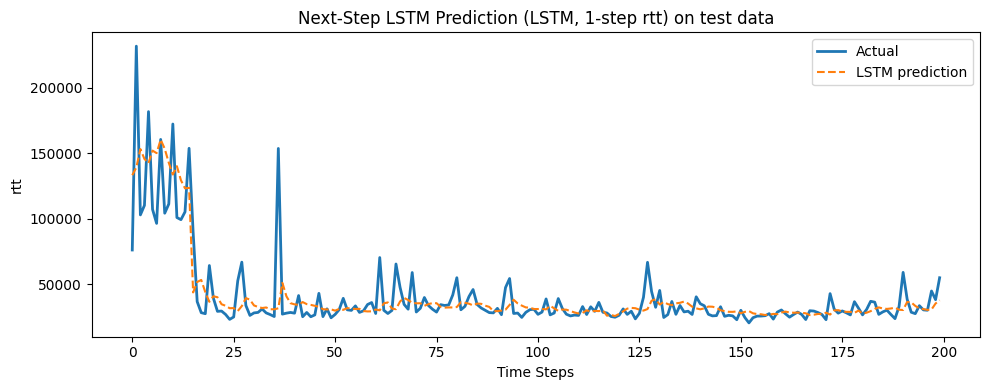

Preparing dataset for target='rtt', lags=10, Horizon=2
Num training windows : 508943, Num validating windows : 127185, Num testing windows : 158510
Begin training: 
LSTM MAE (train): 15161.692383, R^2 (train): 0.647802
LSTM MAE (validate): 13881.970703, R^2 (validate): 0.711260
LSTM MAE (test): 16363.786133, R^2 (test): 0.311709
 Epoch 00 | Train Loss: 0.073417 | Val Loss: 0.048632  

LSTM MAE (train): 15726.229492, R^2 (train): 0.649059
LSTM MAE (validate): 14635.015625, R^2 (validate): 0.712982
LSTM MAE (test): 16950.253906, R^2 (test): 0.318685
 Epoch 01 | Train Loss: 0.056210 | Val Loss: 0.048288  

LSTM MAE (train): 15321.258789, R^2 (train): 0.650820
LSTM MAE (validate): 13670.216797, R^2 (validate): 0.718088
LSTM MAE (test): 16130.506836, R^2 (test): 0.321257
 Epoch 02 | Train Loss: 0.055680 | Val Loss: 0.047351  

LSTM MAE (train): 14753.242188, R^2 (train): 0.651566
LSTM MAE (validate): 12500.742188, R^2 (validate): 0.719331
LSTM MAE (test): 15842.747070, R^2 (test): 0.322739


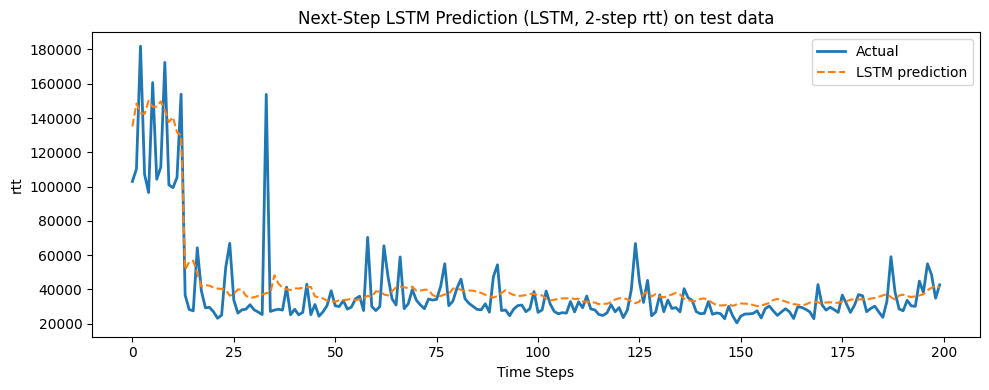

Preparing dataset for target='rtt', lags=10, Horizon=4
Num training windows : 508451, Num validating windows : 127053, Num testing windows : 158274
Begin training: 
LSTM MAE (train): 15869.318359, R^2 (train): 0.649773
LSTM MAE (validate): 15204.710938, R^2 (validate): 0.709121
LSTM MAE (test): 16686.833984, R^2 (test): 0.313002
 Epoch 00 | Train Loss: 0.074817 | Val Loss: 0.049801  

LSTM MAE (train): 15444.050781, R^2 (train): 0.649445
LSTM MAE (validate): 14321.369141, R^2 (validate): 0.711838
LSTM MAE (test): 16578.595703, R^2 (test): 0.313625
 Epoch 01 | Train Loss: 0.056375 | Val Loss: 0.048589  

LSTM MAE (train): 15248.481445, R^2 (train): 0.648068
LSTM MAE (validate): 13790.683594, R^2 (validate): 0.711517
LSTM MAE (test): 16298.519531, R^2 (test): 0.312183
 Epoch 02 | Train Loss: 0.055932 | Val Loss: 0.048102  

LSTM MAE (train): 14832.161133, R^2 (train): 0.648788
LSTM MAE (validate): 12774.983398, R^2 (validate): 0.715384
LSTM MAE (test): 16313.309570, R^2 (test): 0.314771


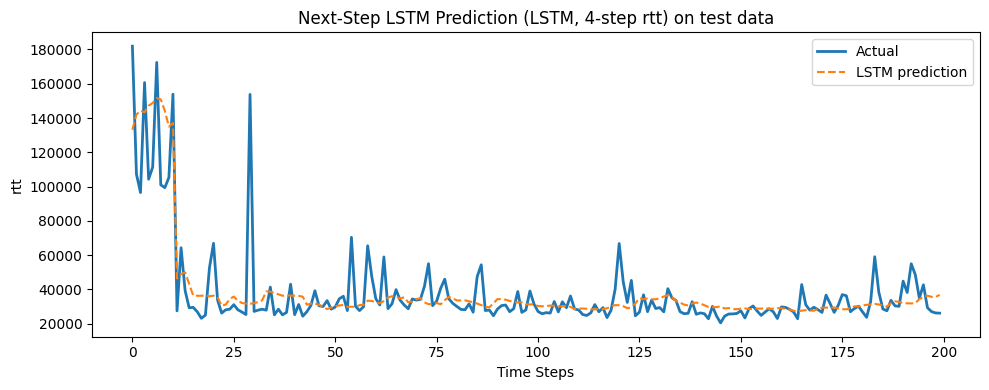

Preparing dataset for target='rtt', lags=10, Horizon=8
Num training windows : 507493, Num validating windows : 126799, Num testing windows : 157813
Begin training: 
LSTM MAE (train): 15518.821289, R^2 (train): 0.648981
LSTM MAE (validate): 14395.898438, R^2 (validate): 0.706114
LSTM MAE (test): 16357.335938, R^2 (test): 0.323809
 Epoch 00 | Train Loss: 0.075072 | Val Loss: 0.049583  

LSTM MAE (train): 15462.308594, R^2 (train): 0.650298
LSTM MAE (validate): 14576.801758, R^2 (validate): 0.708696
LSTM MAE (test): 16532.513672, R^2 (test): 0.324289
 Epoch 01 | Train Loss: 0.056246 | Val Loss: 0.049178  

LSTM MAE (train): 14979.085938, R^2 (train): 0.649126
LSTM MAE (validate): 13753.536133, R^2 (validate): 0.708702
LSTM MAE (test): 16288.786133, R^2 (test): 0.319927
 Epoch 02 | Train Loss: 0.055972 | Val Loss: 0.048671  

LSTM MAE (train): 14943.678711, R^2 (train): 0.649138
LSTM MAE (validate): 13267.075195, R^2 (validate): 0.710922
LSTM MAE (test): 16436.048828, R^2 (test): 0.321004


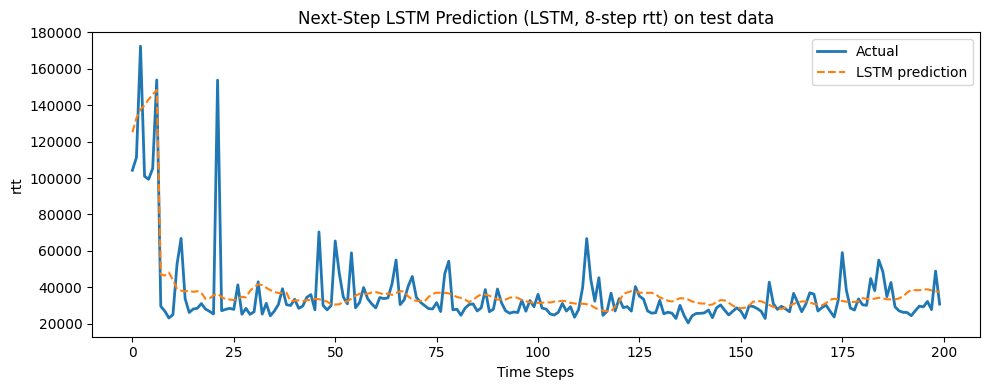

Preparing dataset for target='rtt', lags=10, Horizon=16
Num training windows : 505646, Num validating windows : 126303, Num testing windows : 156926
Begin training: 
LSTM MAE (train): 16245.540039, R^2 (train): 0.642547
LSTM MAE (validate): 15640.081055, R^2 (validate): 0.699409
LSTM MAE (test): 16801.640625, R^2 (test): 0.300261
 Epoch 00 | Train Loss: 0.073987 | Val Loss: 0.050804  

LSTM MAE (train): 15969.820312, R^2 (train): 0.645276
LSTM MAE (validate): 15322.613281, R^2 (validate): 0.705107
LSTM MAE (test): 16951.076172, R^2 (test): 0.303814
 Epoch 01 | Train Loss: 0.056895 | Val Loss: 0.049793  

LSTM MAE (train): 15416.722656, R^2 (train): 0.645558
LSTM MAE (validate): 14261.552734, R^2 (validate): 0.709382
LSTM MAE (test): 16727.486328, R^2 (test): 0.304373
 Epoch 02 | Train Loss: 0.056496 | Val Loss: 0.048620  

LSTM MAE (train): 15137.535156, R^2 (train): 0.645711
LSTM MAE (validate): 13037.416992, R^2 (validate): 0.712322
LSTM MAE (test): 16660.076172, R^2 (test): 0.305394

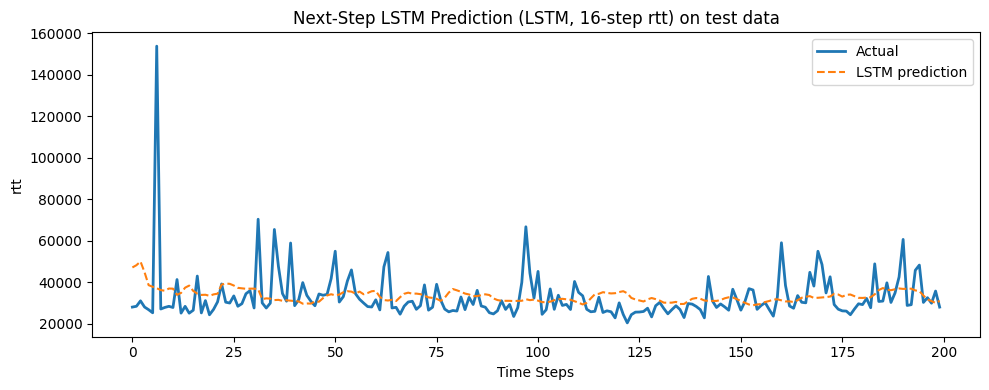

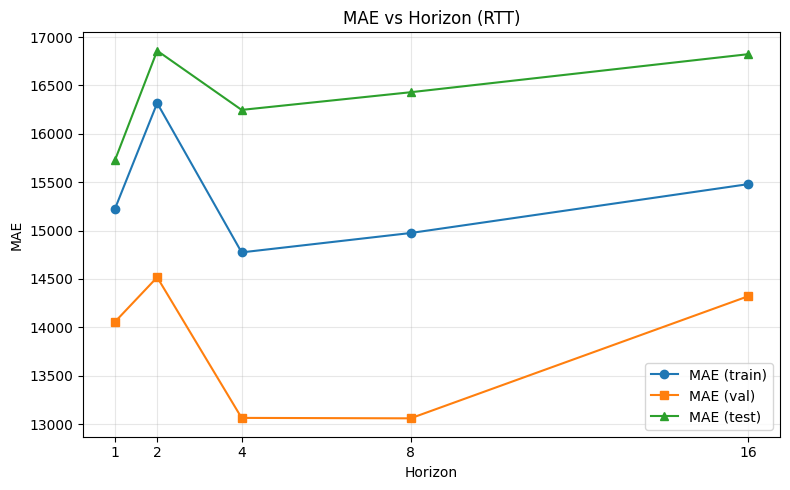

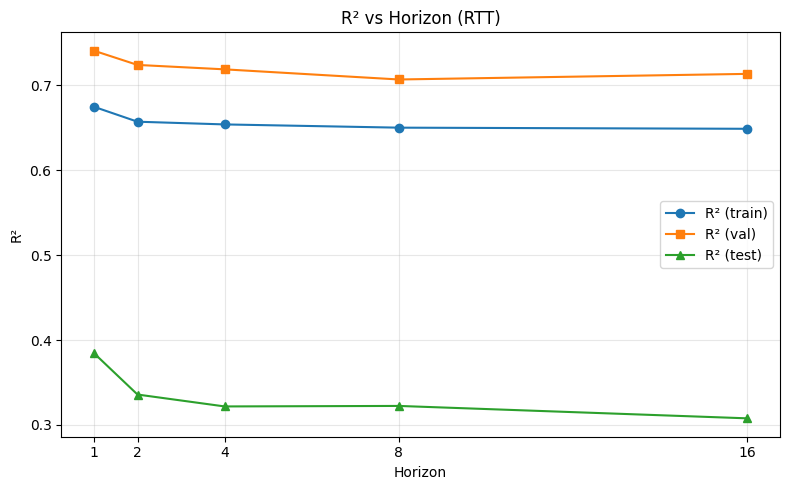

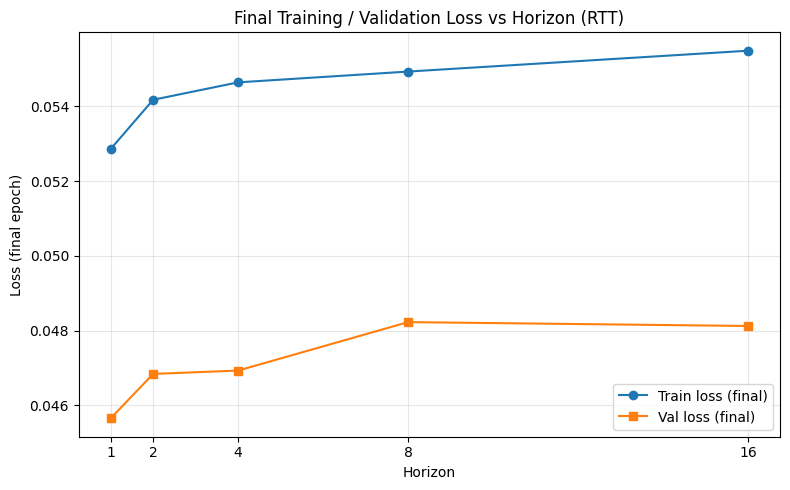

Preparing dataset for target='delivery_rate', lags=10, Horizon=1
Num training windows : 509198, Num validating windows : 127251, Num testing windows : 158631
Begin training: 
LSTM MAE (train): 4246056.500000, R^2 (train): 0.538669
LSTM MAE (validate): 5310343.500000, R^2 (validate): 0.496869
LSTM MAE (test): 2667175.250000, R^2 (test): 0.497648
 Epoch 00 | Train Loss: 0.157719 | Val Loss: 0.221362  

LSTM MAE (train): 4302426.500000, R^2 (train): 0.543698
LSTM MAE (validate): 5303418.500000, R^2 (validate): 0.506515
LSTM MAE (test): 2680503.500000, R^2 (test): 0.511321
 Epoch 01 | Train Loss: 0.148070 | Val Loss: 0.221160  

LSTM MAE (train): 4115575.750000, R^2 (train): 0.518024
LSTM MAE (validate): 5200617.000000, R^2 (validate): 0.479225
LSTM MAE (test): 2585223.250000, R^2 (test): 0.487602
 Epoch 02 | Train Loss: 0.146792 | Val Loss: 0.221065  

LSTM MAE (train): 4075814.000000, R^2 (train): 0.566481
LSTM MAE (validate): 5001847.500000, R^2 (validate): 0.506454
LSTM MAE (test): 265

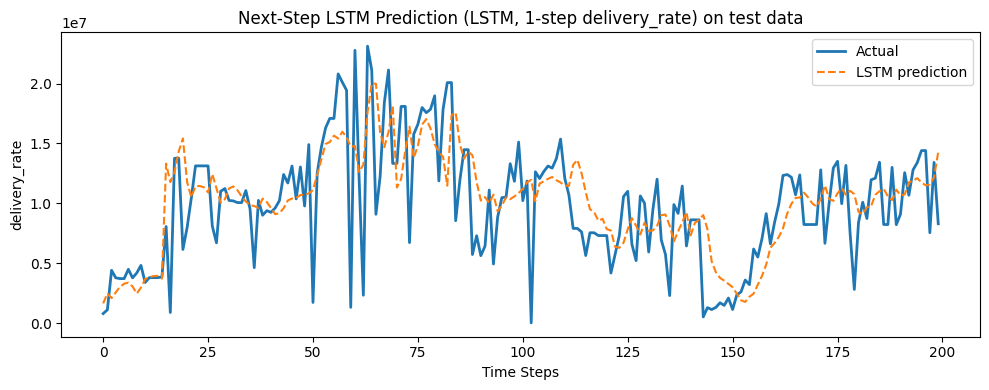

Preparing dataset for target='delivery_rate', lags=10, Horizon=2
Num training windows : 508943, Num validating windows : 127185, Num testing windows : 158510
Begin training: 
LSTM MAE (train): 4145896.000000, R^2 (train): 0.563097
LSTM MAE (validate): 5147283.000000, R^2 (validate): 0.517062
LSTM MAE (test): 2746019.000000, R^2 (test): 0.493471
 Epoch 00 | Train Loss: 0.155971 | Val Loss: 0.207049  

LSTM MAE (train): 3987834.250000, R^2 (train): 0.585369
LSTM MAE (validate): 4798176.500000, R^2 (validate): 0.560273
LSTM MAE (test): 2739868.500000, R^2 (test): 0.517199
 Epoch 01 | Train Loss: 0.129573 | Val Loss: 0.187788  

LSTM MAE (train): 3961767.750000, R^2 (train): 0.603299
LSTM MAE (validate): 4831067.000000, R^2 (validate): 0.573266
LSTM MAE (test): 2741008.750000, R^2 (test): 0.518665
 Epoch 02 | Train Loss: 0.124855 | Val Loss: 0.186393  

LSTM MAE (train): 3801269.750000, R^2 (train): 0.597665
LSTM MAE (validate): 4527076.000000, R^2 (validate): 0.589927
LSTM MAE (test): 262

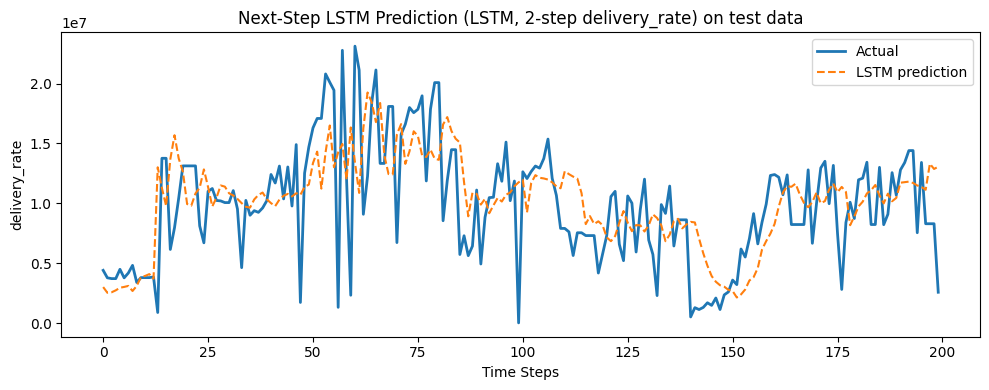

Preparing dataset for target='delivery_rate', lags=10, Horizon=4
Num training windows : 508451, Num validating windows : 127053, Num testing windows : 158274
Begin training: 
LSTM MAE (train): 4379285.500000, R^2 (train): 0.534225
LSTM MAE (validate): 5384444.000000, R^2 (validate): 0.490127
LSTM MAE (test): 2800397.250000, R^2 (test): 0.486565
 Epoch 00 | Train Loss: 0.159897 | Val Loss: 0.224069  

LSTM MAE (train): 3680750.250000, R^2 (train): 0.700636
LSTM MAE (validate): 4391480.000000, R^2 (validate): 0.630924
LSTM MAE (test): 2706765.500000, R^2 (test): 0.504608
 Epoch 01 | Train Loss: 0.141144 | Val Loss: 0.165405  

LSTM MAE (train): 3189813.500000, R^2 (train): 0.750389
LSTM MAE (validate): 3492119.750000, R^2 (validate): 0.726198
LSTM MAE (test): 2447046.750000, R^2 (test): 0.604728
 Epoch 02 | Train Loss: 0.095787 | Val Loss: 0.119727  

LSTM MAE (train): 3055869.000000, R^2 (train): 0.760675
LSTM MAE (validate): 3373986.250000, R^2 (validate): 0.733440
LSTM MAE (test): 237

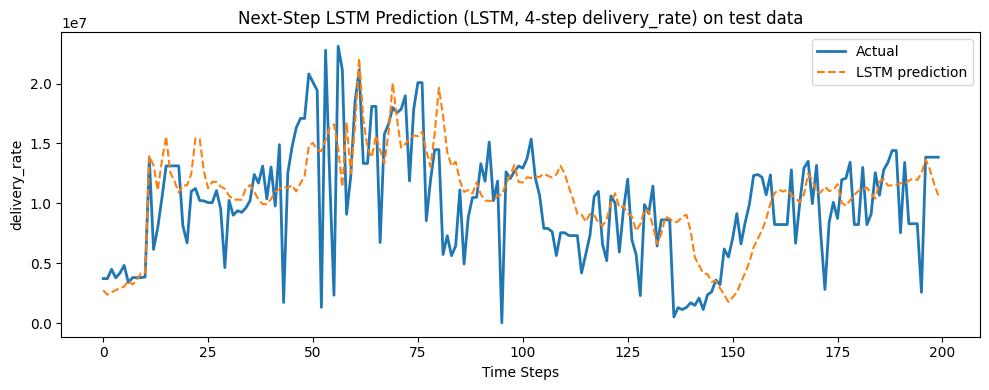

Preparing dataset for target='delivery_rate', lags=10, Horizon=8
Num training windows : 507493, Num validating windows : 126799, Num testing windows : 157813
Begin training: 
LSTM MAE (train): 4358301.000000, R^2 (train): 0.559057
LSTM MAE (validate): 5303317.000000, R^2 (validate): 0.506683
LSTM MAE (test): 2837507.000000, R^2 (test): 0.477468
 Epoch 00 | Train Loss: 0.156967 | Val Loss: 0.215552  

LSTM MAE (train): 4047074.000000, R^2 (train): 0.608192
LSTM MAE (validate): 4895472.500000, R^2 (validate): 0.540634
LSTM MAE (test): 2844892.500000, R^2 (test): 0.470845
 Epoch 01 | Train Loss: 0.132894 | Val Loss: 0.190978  

LSTM MAE (train): 3886258.750000, R^2 (train): 0.628515
LSTM MAE (validate): 4625244.000000, R^2 (validate): 0.566484
LSTM MAE (test): 2729071.000000, R^2 (test): 0.511147
 Epoch 02 | Train Loss: 0.122642 | Val Loss: 0.179654  

LSTM MAE (train): 3784570.500000, R^2 (train): 0.640140
LSTM MAE (validate): 4451710.500000, R^2 (validate): 0.595683
LSTM MAE (test): 268

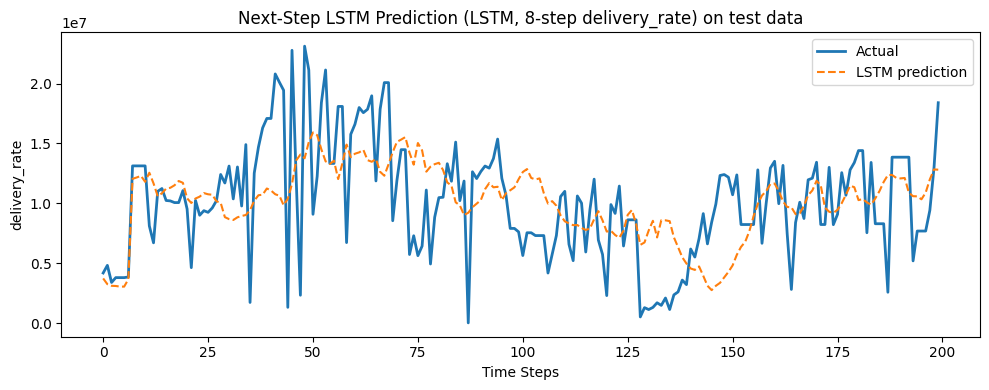

Preparing dataset for target='delivery_rate', lags=10, Horizon=16
Num training windows : 505646, Num validating windows : 126303, Num testing windows : 156926
Begin training: 
LSTM MAE (train): 4599388.500000, R^2 (train): 0.512527
LSTM MAE (validate): 5610408.000000, R^2 (validate): 0.444189
LSTM MAE (test): 3007049.000000, R^2 (test): 0.431865
 Epoch 00 | Train Loss: 0.165362 | Val Loss: 0.236432  

LSTM MAE (train): 4189015.500000, R^2 (train): 0.620480
LSTM MAE (validate): 5143964.500000, R^2 (validate): 0.498920
LSTM MAE (test): 2982244.500000, R^2 (test): 0.442383
 Epoch 01 | Train Loss: 0.153384 | Val Loss: 0.204713  

LSTM MAE (train): 3654821.000000, R^2 (train): 0.706965
LSTM MAE (validate): 4076175.000000, R^2 (validate): 0.646654
LSTM MAE (test): 2801520.000000, R^2 (test): 0.530061
 Epoch 02 | Train Loss: 0.109617 | Val Loss: 0.145955  

LSTM MAE (train): 3531434.750000, R^2 (train): 0.714531
LSTM MAE (validate): 3911838.250000, R^2 (validate): 0.658265
LSTM MAE (test): 27

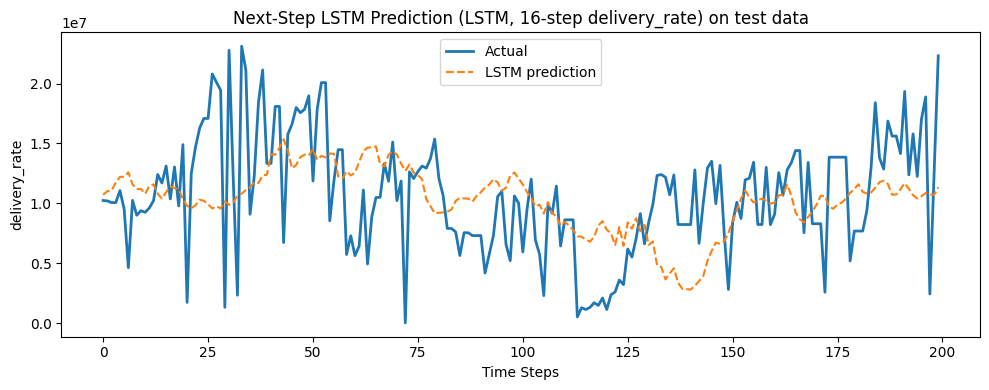

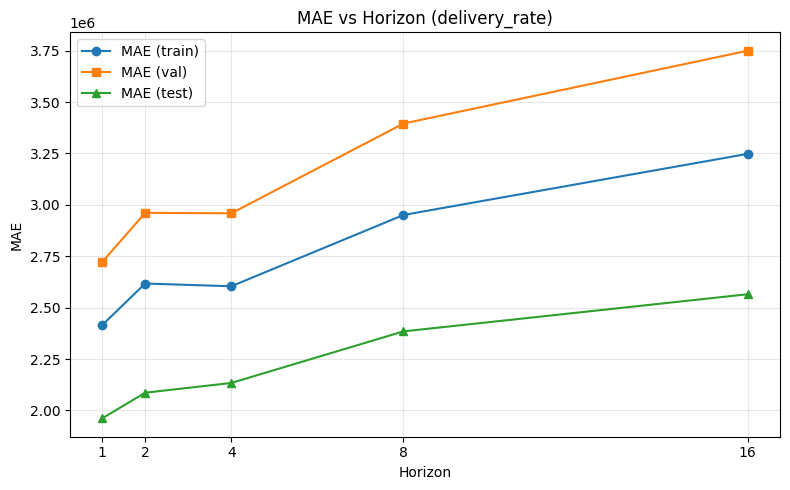

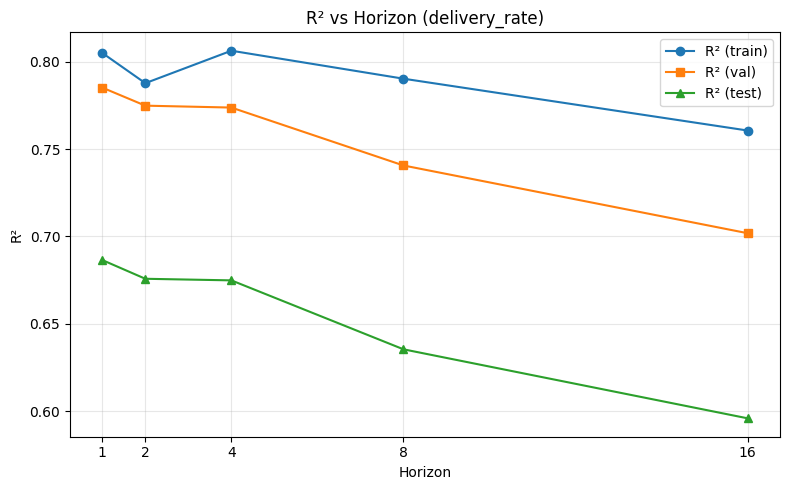

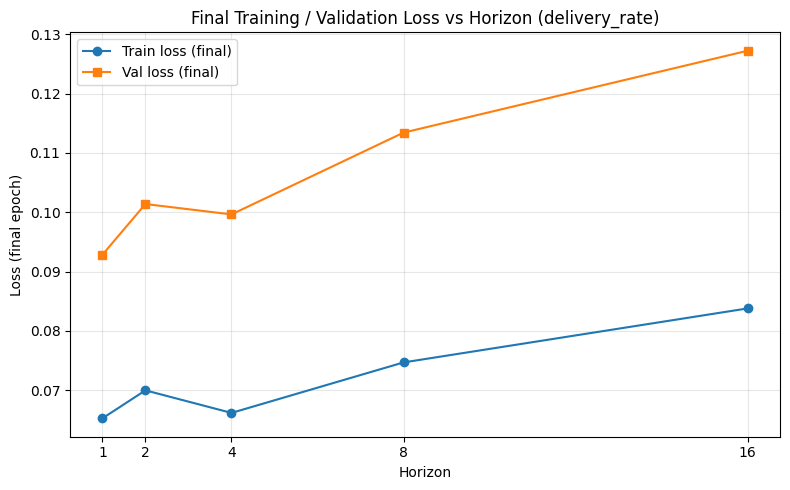

In [158]:
df = load_puffer_dataset()
mae_train = []
mae_val = []
mae_test = []
r2_train = []
r2_val = []
r2_test = []
train_loss_final = []
val_loss_final = []
models = {}
for i in [1, 2, 4, 8, 16]:
    model, data = train_lstm_timeseries(df, target_metric='rtt', n_lags=SEQ_LEN, horizon=i, sample_size=800000)
    models[f"model_{i}_reg_rtt"] = [model, data]
    mae_test_val = data.get('MAE', None)
    r2_test_val = data.get('R2', None)
    mae_val_val  = data.get('val_mae', None)
    r2_val_val   = data.get('val_R2', None)
    mae_train_val = data.get('train_mae', None)
    r2_train_val  = data.get('train_R2', None)
    train_loss_val = data.get('train_loss', None)
    val_loss_val   = data.get('val_loss', None)
    mae_test.append(float(mae_test_val))
    r2_test.append(float(r2_test_val))
    mae_val.append(float(mae_val_val))
    r2_val.append(float(r2_val_val))
    mae_train.append(float(mae_train_val))
    r2_train.append(float(r2_train_val))
    train_loss_final.append(float(train_loss_val))
    val_loss_final.append(float(val_loss_val))

# Convert to numpy arrays for plotting
h_arr = np.array([1, 2, 4, 8, 16])
mae_train = np.array(mae_train)
mae_val = np.array(mae_val)
mae_test = np.array(mae_test)
r2_train = np.array(r2_train)
r2_val = np.array(r2_val)
r2_test = np.array(r2_test)
train_loss_final = np.array(train_loss_final)
val_loss_final = np.array(val_loss_final)

# --- Plot 1: MAE vs Horizon ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, mae_train, marker='o', label='MAE (train)')
plt.plot(h_arr, mae_val, marker='s', label='MAE (val)')
plt.plot(h_arr, mae_test, marker='^', label='MAE (test)')
plt.xlabel('Horizon')
plt.ylabel('MAE')
plt.title('MAE vs Horizon (RTT)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: R^2 vs Horizon ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, r2_train, marker='o', label='R² (train)')
plt.plot(h_arr, r2_val, marker='s', label='R² (val)')
plt.plot(h_arr, r2_test, marker='^', label='R² (test)')
plt.xlabel('Horizon')
plt.ylabel('R²')
plt.title('R² vs Horizon (RTT)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: Training Losses vs Horizon (final epoch) ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, train_loss_final, marker='o', label='Train loss (final)')
plt.plot(h_arr, val_loss_final, marker='s', label='Val loss (final)')
plt.xlabel('Horizon')
plt.ylabel('Loss (final epoch)')
plt.title('Final Training / Validation Loss vs Horizon (RTT)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

mae_train = []
mae_val = []
mae_test = []
r2_train = []
r2_val = []
r2_test = []
train_loss_final = []
val_loss_final = []
for i in [1, 2, 4, 8, 16]:
    model, data = train_lstm_timeseries(df, target_metric='delivery_rate', n_lags=SEQ_LEN, horizon=i, sample_size=800000)
    models[f"model_{i}_reg_delivery_rate"] = [model, data]
    mae_test_val = data.get('MAE', None)
    r2_test_val = data.get('R2', None)
    mae_val_val  = data.get('val_mae', None)
    r2_val_val   = data.get('val_R2', None)
    mae_train_val = data.get('train_mae', None)
    r2_train_val  = data.get('train_R2', None)
    train_loss_val = data.get('train_loss', None)
    val_loss_val   = data.get('val_loss', None)
    mae_test.append(float(mae_test_val))
    r2_test.append(float(r2_test_val))
    mae_val.append(float(mae_val_val))
    r2_val.append(float(r2_val_val))
    mae_train.append(float(mae_train_val))
    r2_train.append(float(r2_train_val))
    train_loss_final.append(float(train_loss_val))
    val_loss_final.append(float(val_loss_val))

# Convert to numpy arrays for plotting
h_arr = np.array([1, 2, 4, 8, 16])
mae_train = np.array(mae_train)
mae_val = np.array(mae_val)
mae_test = np.array(mae_test)
r2_train = np.array(r2_train)
r2_val = np.array(r2_val)
r2_test = np.array(r2_test)
train_loss_final = np.array(train_loss_final)
val_loss_final = np.array(val_loss_final)

# --- Plot 1: MAE vs Horizon ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, mae_train, marker='o', label='MAE (train)')
plt.plot(h_arr, mae_val, marker='s', label='MAE (val)')
plt.plot(h_arr, mae_test, marker='^', label='MAE (test)')
plt.xlabel('Horizon')
plt.ylabel('MAE')
plt.title('MAE vs Horizon (delivery_rate)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 2: R^2 vs Horizon ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, r2_train, marker='o', label='R² (train)')
plt.plot(h_arr, r2_val, marker='s', label='R² (val)')
plt.plot(h_arr, r2_test, marker='^', label='R² (test)')
plt.xlabel('Horizon')
plt.ylabel('R²')
plt.title('R² vs Horizon (delivery_rate)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot 3: Training Losses vs Horizon (final epoch) ---
plt.figure(figsize=(8,5))
plt.plot(h_arr, train_loss_final, marker='o', label='Train loss (final)')
plt.plot(h_arr, val_loss_final, marker='s', label='Val loss (final)')
plt.xlabel('Horizon')
plt.ylabel('Loss (final epoch)')
plt.title('Final Training / Validation Loss vs Horizon (delivery_rate)')
plt.xticks(h_arr)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Preparing dataset for target='rtt', lags=10, Horizon=1
Num training windows : 509198, Num validating windows : 127251, Num testing windows : 158631
Training 4 quantiles, [0.1, 0.25, 0.75, 0.9]
Begin training: 
LSTM MAE (train): 15709.088867, R^2 (train): 0.631566
LSTM MAE (validate): 14441.708984, R^2 (validate): 0.674607
LSTM MAE (test): 17280.539062, R^2 (test): 0.287228
Epoch 00 | Train Loss: 0.075015 | Val Loss: 0.050483  

LSTM MAE (train): 16223.756836, R^2 (train): 0.619120
LSTM MAE (validate): 14649.977539, R^2 (validate): 0.664382
LSTM MAE (test): 18391.384766, R^2 (test): 0.258378
Epoch 01 | Train Loss: 0.044679 | Val Loss: 0.044572  

LSTM MAE (train): 15810.233398, R^2 (train): 0.611415
LSTM MAE (validate): 14198.315430, R^2 (validate): 0.655104
LSTM MAE (test): 18261.333984, R^2 (test): 0.242335
Epoch 02 | Train Loss: 0.043019 | Val Loss: 0.042862  

LSTM MAE (train): 15195.232422, R^2 (train): 0.609550
LSTM MAE (validate): 13860.862305, R^2 (validate): 0.650697
LSTM MAE (

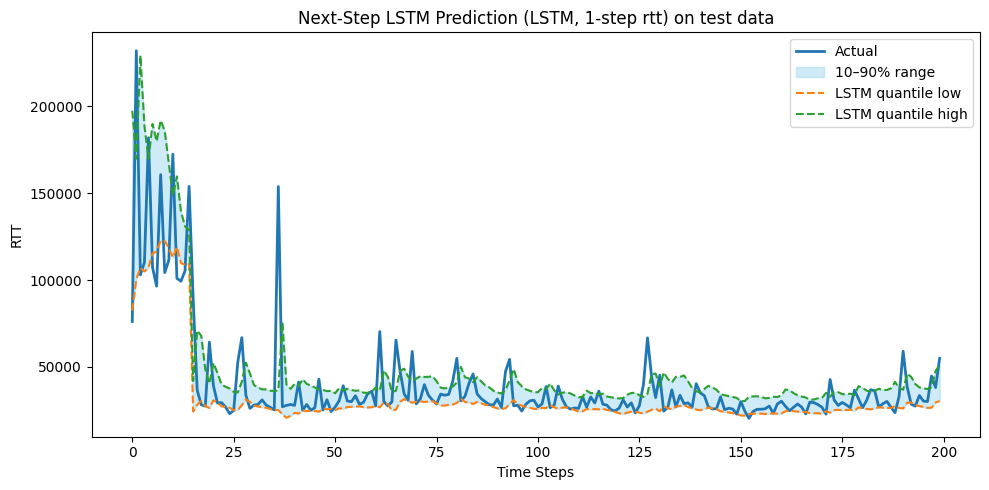

Coverage: 44.26% | Avg. interval width: 16571.1875


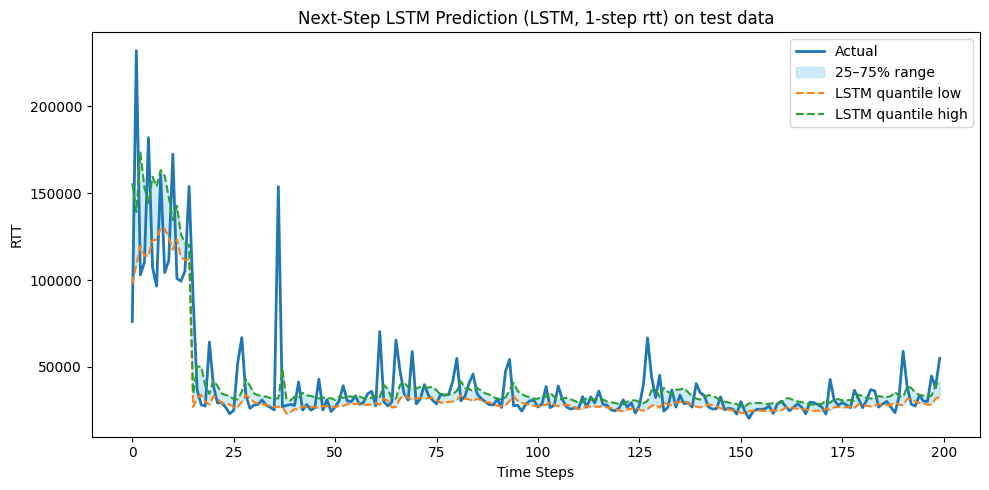

Preparing dataset for target='rtt', lags=10, Horizon=2
Num training windows : 508943, Num validating windows : 127185, Num testing windows : 158510
Training 4 quantiles, [0.1, 0.25, 0.75, 0.9]
Begin training: 
LSTM MAE (train): 15937.441406, R^2 (train): 0.626266
LSTM MAE (validate): 14067.697266, R^2 (validate): 0.667819
LSTM MAE (test): 17916.552734, R^2 (test): 0.271003
Epoch 00 | Train Loss: 0.073393 | Val Loss: 0.048307  

LSTM MAE (train): 16916.832031, R^2 (train): 0.611207
LSTM MAE (validate): 15609.057617, R^2 (validate): 0.653888
LSTM MAE (test): 18873.281250, R^2 (test): 0.241658
Epoch 01 | Train Loss: 0.044567 | Val Loss: 0.045503  

LSTM MAE (train): 15511.494141, R^2 (train): 0.604597
LSTM MAE (validate): 13948.946289, R^2 (validate): 0.642796
LSTM MAE (test): 17367.693359, R^2 (test): 0.236400
Epoch 02 | Train Loss: 0.043179 | Val Loss: 0.043517  

LSTM MAE (train): 15005.071289, R^2 (train): 0.610262
LSTM MAE (validate): 13145.242188, R^2 (validate): 0.651721
LSTM MAE (

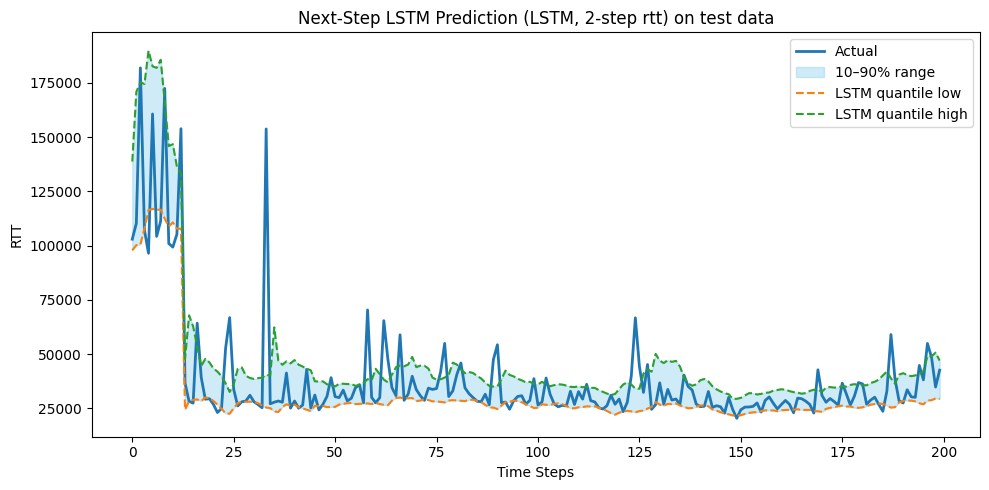

Coverage: 44.69% | Avg. interval width: 16977.3555


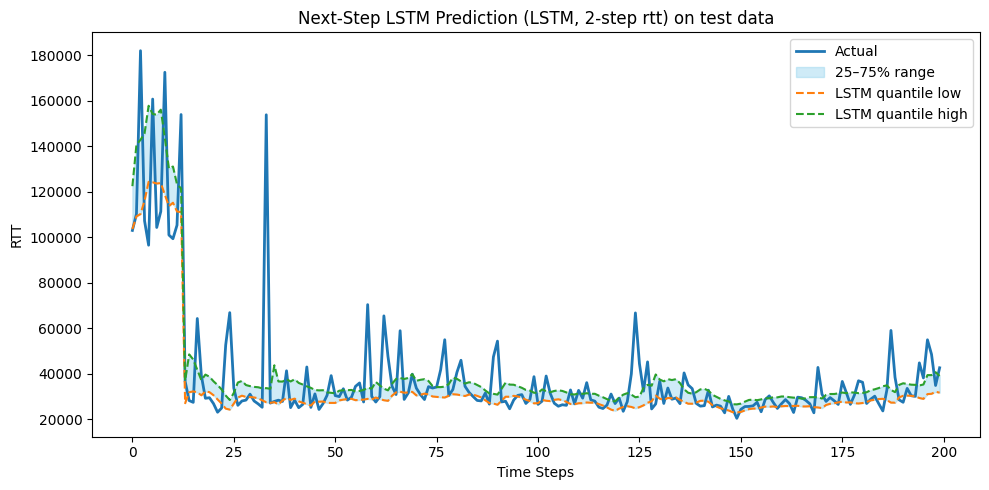

Preparing dataset for target='rtt', lags=10, Horizon=4
Num training windows : 508451, Num validating windows : 127053, Num testing windows : 158274
Training 4 quantiles, [0.1, 0.25, 0.75, 0.9]
Begin training: 
LSTM MAE (train): 15560.071289, R^2 (train): 0.624839
LSTM MAE (validate): 13467.157227, R^2 (validate): 0.659730
LSTM MAE (test): 17516.533203, R^2 (test): 0.270754
Epoch 00 | Train Loss: 0.072201 | Val Loss: 0.048267  

LSTM MAE (train): 15213.161133, R^2 (train): 0.613722
LSTM MAE (validate): 13264.179688, R^2 (validate): 0.654586
LSTM MAE (test): 17315.390625, R^2 (test): 0.247683
Epoch 01 | Train Loss: 0.044390 | Val Loss: 0.044887  

LSTM MAE (train): 15517.581055, R^2 (train): 0.606687
LSTM MAE (validate): 13889.125000, R^2 (validate): 0.644002
LSTM MAE (test): 17694.099609, R^2 (test): 0.237994
Epoch 02 | Train Loss: 0.043133 | Val Loss: 0.042987  

LSTM MAE (train): 15622.809570, R^2 (train): 0.599912
LSTM MAE (validate): 14025.307617, R^2 (validate): 0.637903
LSTM MAE (

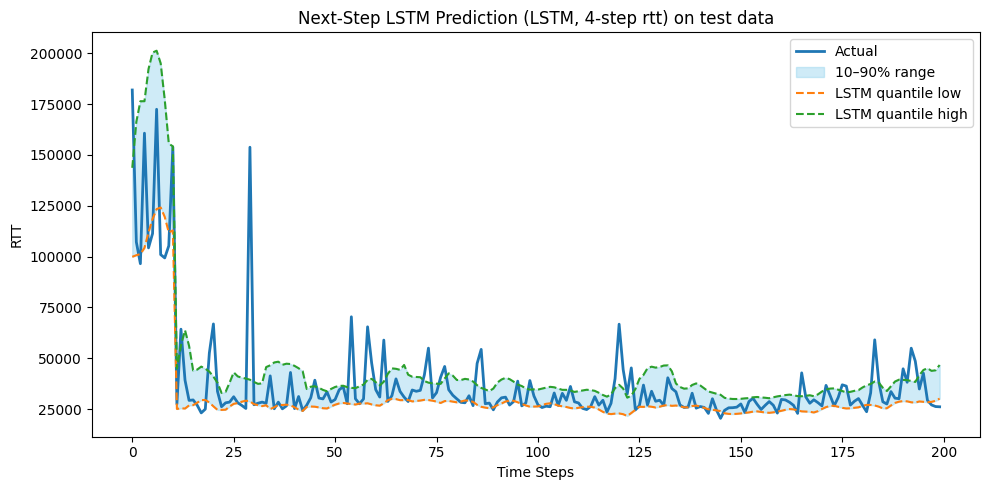

Coverage: 42.72% | Avg. interval width: 16729.0430


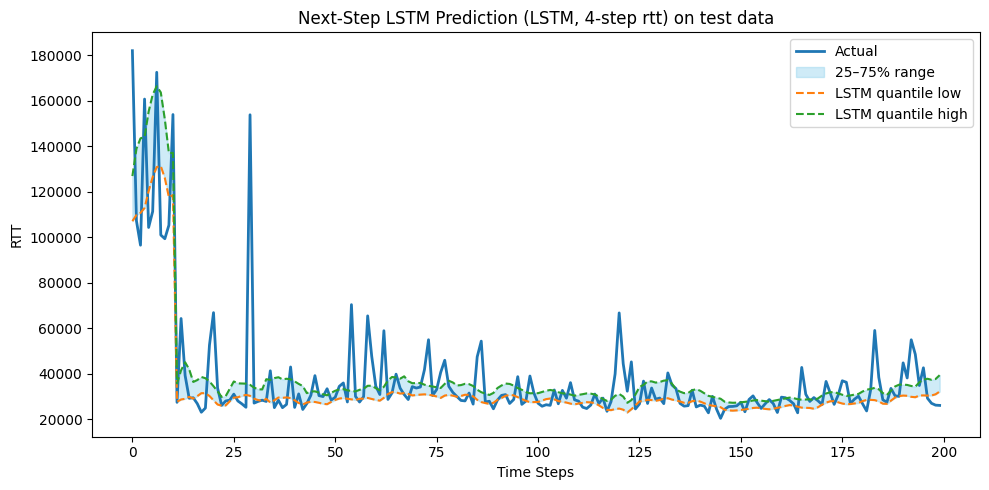

Preparing dataset for target='rtt', lags=10, Horizon=8
Num training windows : 507493, Num validating windows : 126799, Num testing windows : 157813
Training 4 quantiles, [0.1, 0.25, 0.75, 0.9]
Begin training: 
LSTM MAE (train): 15353.097656, R^2 (train): 0.634076
LSTM MAE (validate): 13408.876953, R^2 (validate): 0.673400
LSTM MAE (test): 16957.820312, R^2 (test): 0.299414
Epoch 00 | Train Loss: 0.075791 | Val Loss: 0.051132  

LSTM MAE (train): 15801.946289, R^2 (train): 0.617414
LSTM MAE (validate): 13842.228516, R^2 (validate): 0.654902
LSTM MAE (test): 18236.724609, R^2 (test): 0.256237
Epoch 01 | Train Loss: 0.044744 | Val Loss: 0.045858  

LSTM MAE (train): 15542.241211, R^2 (train): 0.611326
LSTM MAE (validate): 13772.042969, R^2 (validate): 0.647687
LSTM MAE (test): 17837.167969, R^2 (test): 0.247996
Epoch 02 | Train Loss: 0.043298 | Val Loss: 0.043627  

LSTM MAE (train): 15925.854492, R^2 (train): 0.599437
LSTM MAE (validate): 14367.961914, R^2 (validate): 0.631405
LSTM MAE (

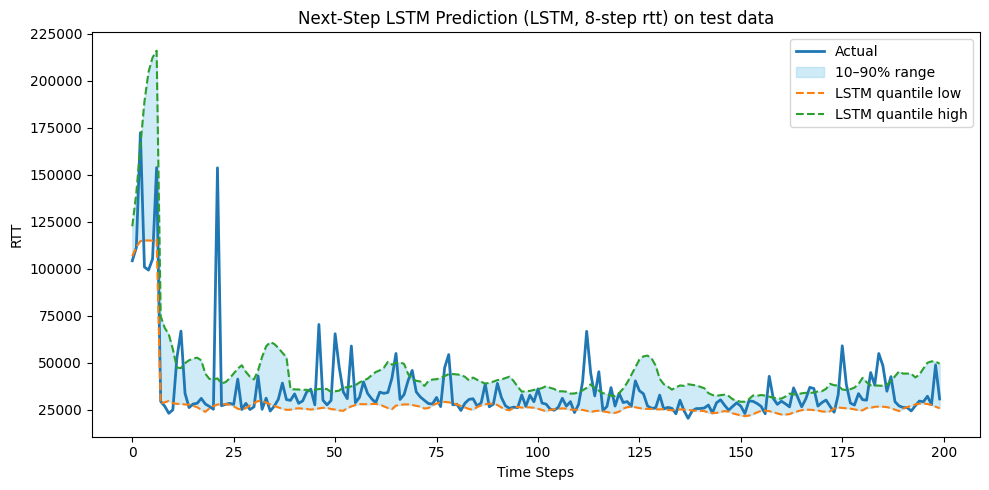

Coverage: 44.04% | Avg. interval width: 17776.4434


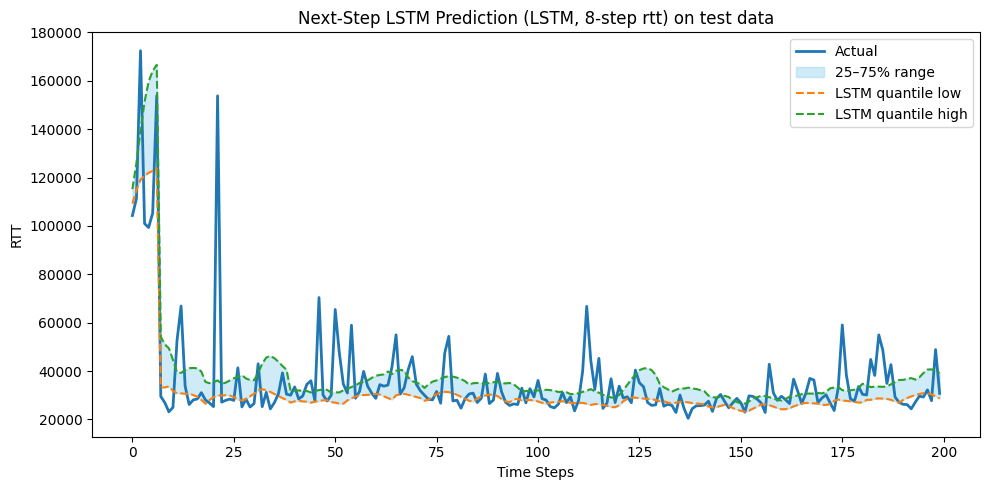

Preparing dataset for target='rtt', lags=10, Horizon=16
Num training windows : 505646, Num validating windows : 126303, Num testing windows : 156926
Training 4 quantiles, [0.1, 0.25, 0.75, 0.9]
Begin training: 
LSTM MAE (train): 16073.687500, R^2 (train): 0.618822
LSTM MAE (validate): 14153.955078, R^2 (validate): 0.651818
LSTM MAE (test): 17898.300781, R^2 (test): 0.260593
Epoch 00 | Train Loss: 0.072081 | Val Loss: 0.049043  

LSTM MAE (train): 15462.577148, R^2 (train): 0.612959
LSTM MAE (validate): 13613.806641, R^2 (validate): 0.651585
LSTM MAE (test): 17916.300781, R^2 (test): 0.237976
Epoch 01 | Train Loss: 0.045097 | Val Loss: 0.046427  

LSTM MAE (train): 15421.463867, R^2 (train): 0.607602
LSTM MAE (validate): 13467.690430, R^2 (validate): 0.645850
LSTM MAE (test): 17738.939453, R^2 (test): 0.230704
Epoch 02 | Train Loss: 0.043829 | Val Loss: 0.044472  

LSTM MAE (train): 15738.571289, R^2 (train): 0.598746
LSTM MAE (validate): 13752.657227, R^2 (validate): 0.637937
LSTM MAE 

In [ ]:
all_coverages = {}
all_band_widths = {}
horizons = list([1, 2, 4, 8, 16])
labels = ['10-90%', '25-75%']
########################################################## RTT

for i in [1, 2, 4, 8, 16]:
    model, data = train_lstm_timeseries_quantile(df, target_metric='rtt', n_lags=SEQ_LEN, horizon=i, sample_size=800000)
    models[f"model_{i}_quantile_rtt"] = [model, data]

    # Plot predictions vs actual values (we will plot only the first 200 rows)
    pairs = data['quantile_pair']
    preds = data['preds']
    trues = data['trues']
    target_std = data['target_std']
    target_mean = data['target_mean']
    qs = data['quantiles']
    y_true = trues * target_std + target_mean
    coverages = []
    band_widths = []
    for low, high in pairs:
        plt.figure(figsize=(10,5))
        low_pred_scaled = preds[:, qs.index(low)]
        high_pred_scaled = preds[:, qs.index(high)]
        y_preds_low = low_pred_scaled * target_std + target_mean
        y_preds_high = high_pred_scaled * target_std + target_mean
        inside = (y_true >= y_preds_low) & (y_true <= y_preds_high)
        coverage = inside.mean() * 100.0  # percentage
        avg_width = np.mean(y_preds_high - y_preds_low)
        coverages.append(coverage)
        band_widths.append(avg_width)
        print(f"Coverage: {coverage:.2f}% | Avg. interval width: {avg_width:.4f}")
        plt.plot(y_true[:200], label='Actual', linewidth=2)
        plt.fill_between(
                np.arange(200),
                y_preds_low[:200],
                y_preds_high[:200],
                color='skyblue',
                alpha=0.4,
                label=f'{int(low*100)}–{int(high*100)}% range'
            )
        plt.plot(y_preds_low[:200], label='LSTM quantile low', linestyle='--')
        plt.plot(y_preds_high[:200], label='LSTM quantile high', linestyle='--')
        plt.title(f'Next-Step LSTM Prediction (LSTM, {i}-step rtt) on test data')
        plt.xlabel('Time Steps')
        plt.ylabel('RTT')
        plt.legend()
        plt.tight_layout()
        plt.show()
    all_coverages[f'horizon_{i}'] = coverages
    all_band_widths[f'horizon_{i}'] = band_widths

coverage_array = np.array([all_coverages[f'horizon_{h}'] for h in horizons])
width_array = np.array([all_band_widths[f'horizon_{h}'] for h in horizons])
x = np.arange(5)  # horizon positions
bar_width = 0.3              # 2 bars per horizon
offsets = [-bar_width/2, bar_width/2]  # left, center, right bars
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ax = axes[0]
for i in range(2):  # 2 quantile ranges
    ax.bar(x + offsets[i], coverage_array[:, i], 
           width=bar_width, label=labels[i])
ax.set_title("RTT Coverage Across Horizons")
ax.set_xlabel("Horizon")
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x)
ax.set_xticklabels([h for h in horizons])
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
for i in range(2):  
    ax.bar(x + offsets[i], width_array[:, i], 
           width=bar_width, label=labels[i])
ax.set_title("RTT Prediction Interval Width Across Horizons")
ax.set_xlabel("Horizon")
ax.set_ylabel("Mean Interval Width")
ax.set_xticks(x)
ax.set_xticklabels([h for h in horizons])
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

########################################################## Deliverate Rate
all_coverages = {}
all_band_widths = {}
labels = ['10-90%', '25-75%']
for i in [1, 2, 4, 8, 16]:
    model, data = train_lstm_timeseries_quantile(df, target_metric='delivery_rate', n_lags=SEQ_LEN, horizon=i, sample_size=800000)
    models[f"model_{i}_quantile_delivery_rate"] = [model, data]
    
    # Plot predictions vs actual values (we will plot only the first 200 rows)
    pairs = data['quantile_pair']
    preds = data['preds']
    trues = data['trues']
    target_std = data['target_std']
    target_mean = data['target_mean']
    qs = data['quantiles']
    y_true = trues * target_std + target_mean
    coverages = []
    band_widths = []
    for low, high in pairs:
        plt.figure(figsize=(10,5))
        low_pred_scaled = preds[:, qs.index(low)]
        high_pred_scaled = preds[:, qs.index(high)]
        y_preds_low = low_pred_scaled * target_std + target_mean
        y_preds_high = high_pred_scaled * target_std + target_mean
        inside = (y_true >= y_preds_low) & (y_true <= y_preds_high)
        coverage = inside.mean() * 100.0  # percentage
        avg_width = np.mean(y_preds_high - y_preds_low)
        coverages.append(coverage)
        band_widths.append(avg_width)
        print(f"Coverage: {coverage:.2f}% | Avg. interval width: {avg_width:.4f}")
    
        plt.plot(y_true[:200], label='Actual', linewidth=2)
        plt.fill_between(
                np.arange(200),
                y_preds_low[:200],
                y_preds_high[:200],
                color='skyblue',
                alpha=0.4,
                label=f'{int(low*100)}–{int(high*100)}% range'
            )
        plt.plot(y_preds_low[:200], label='LSTM quantile low', linestyle='--')
        plt.plot(y_preds_high[:200], label='LSTM quantile high', linestyle='--')
        plt.title(f'Next-Step LSTM Prediction (LSTM, {i}-step delivery_rate) on test data')
        plt.xlabel('Time Steps')
        plt.ylabel('RTT')
        plt.legend()
        plt.tight_layout()
        plt.show()
    all_coverages[f'horizon_{i}'] = coverages
    all_band_widths[f'horizon_{i}'] = band_widths
    
coverage_array = np.array([all_coverages[f'horizon_{h}'] for h in horizons])
width_array = np.array([all_band_widths[f'horizon_{h}'] for h in horizons])
x = np.arange(5)  # horizon positions
bar_width = 0.3              # 2 bars per horizon
offsets = [-bar_width/2, bar_width/2]  # left, center, right bars
fig, axes = plt.subplots(1, 2, figsize=(10,4))
ax = axes[0]
for i in range(2):  # 2 quantile ranges
    ax.bar(x + offsets[i], coverage_array[:, i], 
           width=bar_width, label=labels[i])
ax.set_title("Delivery_rate Coverage Across Horizons")
ax.set_xlabel("Horizon")
ax.set_ylabel("Coverage (%)")
ax.set_xticks(x)
ax.set_xticklabels([h for h in horizons])
ax.legend()
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
for i in range(2):  
    ax.bar(x + offsets[i], width_array[:, i], 
           width=bar_width, label=labels[i])
ax.set_title("Delivery_rate Prediction Interval Width Across Horizons")
ax.set_xlabel("Horizon")
ax.set_ylabel("Mean Interval Width")
ax.set_xticks(x)
ax.set_xticklabels([h for h in horizons])
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()